# 🌡️ FLIR Thermal — Object Detection with YOLOv8s  (v2)

| | |
|---|---|
| **Dataset** | [FLIR Thermal Reduced](https://www.kaggle.com/datasets/albertofv/flir-thermal-images-dataset-reduced) |
| **Model** | YOLOv8s (pretrained COCO) |
| **Classes** | `person` `car` `bike` |
| **Training** | Single phase · Warmup · Differential LR |

> Make sure **Runtime → Change runtime type → GPU (T4)** is selected.

## 1 · Packages & Global Config

In [1]:
!pip install ultralytics kaggle --quiet

import os, json, zipfile, random, shutil, subprocess, warnings
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm
import torch
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, matthews_corrcoef, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

# ---- Paths ---------------------------------------------------------------
ROOT        = Path('/content/flir_work')
RAW_DIR     = ROOT / 'raw'
DATASET_DIR = ROOT / 'dataset'
RUNS_DIR    = ROOT / 'runs'
YAML_PATH   = ROOT / 'flir_thermal.yaml'
SAVE_DIR    = ROOT / 'outputs'
for d in [ROOT, RAW_DIR, DATASET_DIR, RUNS_DIR, SAVE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- Class config (3 classes — light/sign removed) ----------------------
YOLO_NAMES = {0: 'person', 1: 'car', 2: 'bike'}
N_CLS      = 3
CLS_COLORS = {0: (255, 80, 80), 1: (80, 80, 255), 2: (80, 200, 80)}
KEYWORD_MAP = {
    'person': 0,
    'car':    1,
    'bicycle':2,
    'bike':   2,
}

CONF_THRESH = 0.15   # inference confidence threshold

# ---- GPU check -----------------------------------------------------------
print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
print(f'Outputs will be saved to: {SAVE_DIR}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch 2.11.0+cu128  |  CUDA: True
GPU: Tesla T4
Tesla T4, 15360 MiB
Outputs will be saved to: /content/flir_work/outputs


## 2 · Dataset Download

Upload `kaggle.json` when prompted (*kaggle.com → Account → API → Create New Token*).

In [ ]:
from google.colab import files as colab_files

kdir  = Path('/root/.config/kaggle')
kdir.mkdir(parents=True, exist_ok=True)
kjson = kdir / 'kaggle.json'
if not kjson.exists():
    print('Upload kaggle.json:')
    up = colab_files.upload()
    for name, data in up.items():
        kjson.write_bytes(data)
    kjson.chmod(0o600)

zip_file = ROOT / 'flir-thermal-images-dataset-reduced.zip'
if not (RAW_DIR / 'train').exists():
    if not zip_file.exists():
        print('Downloading...')
        subprocess.run(
            ['kaggle', 'datasets', 'download',
             '-d', 'albertofv/flir-thermal-images-dataset-reduced',
             '--path', str(ROOT)],
            check=True
        )
    print('Unzipping...')
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(RAW_DIR)
    print('Done.')
else:
    print('Already extracted.')

def find_split(base, name):
    direct = base / name
    if direct.is_dir() and (direct / 'thermal_8_bit').is_dir():
        return direct
    for p in base.rglob(name):
        if p.is_dir() and (p / 'thermal_8_bit').is_dir():
            return p
    raise FileNotFoundError(f'{name} not found')

TRAIN_RAW = find_split(RAW_DIR, 'train')
VAL_RAW   = find_split(RAW_DIR, 'val')

n_tr = len(list((TRAIN_RAW/'thermal_8_bit').glob('*.jpeg')))
n_va = len(list((VAL_RAW/'thermal_8_bit').glob('*.jpeg')))
print(f'Train: {n_tr} images  |  Val: {n_va} images')


## 3 · Annotation Conversion (COCO → YOLO)

Keeping only `person` `car` `bike`. BBox format: `[x, y, w, h]` absolute → `[xc, yc, w, h]` normalised.

In [3]:
def build_cat_map(categories):
    mapping = {}
    for cat in categories:
        nl = cat['name'].lower()
        for kw, yid in KEYWORD_MAP.items():
            if kw in nl and cat['id'] not in mapping:
                mapping[cat['id']] = yid
                break
    return mapping


def coco_to_yolo(split_raw, split_name):
    img_dir    = split_raw / 'thermal_8_bit'
    ann_file   = split_raw / 'thermal_annotations.json'
    dst_labels = DATASET_DIR / 'labels' / split_name
    dst_labels.mkdir(parents=True, exist_ok=True)

    with open(ann_file) as f:
        coco = json.load(f)

    cat_map = build_cat_map(coco['categories'])

    if 'images' in coco:
        id2file = {img['id']: Path(img['file_name']).name
                   for img in coco['images']}
    else:
        files   = sorted(img_dir.glob('*.jpeg'))
        id2file = {i: f.name for i, f in enumerate(files)}

    ann_by_img = defaultdict(list)
    for ann in coco['annotations']:
        if ann.get('iscrowd', 0) == 0 and ann['category_id'] in cat_map:
            ann_by_img[ann['image_id']].append(ann)

    converted = 0
    for img_id, anns in ann_by_img.items():
        fname = id2file.get(img_id)
        if not fname:
            continue
        src = img_dir / fname
        if not src.exists():
            continue
        tmp = cv2.imread(str(src))
        if tmp is None:
            continue
        h_px, w_px = tmp.shape[:2]

        lines = []
        for ann in anns:
            bx, by, bw, bh = ann['bbox']
            xc = float(np.clip((bx + bw/2) / w_px, 0, 1))
            yc = float(np.clip((by + bh/2) / h_px, 0, 1))
            wn = float(np.clip(bw / w_px, 0, 1))
            hn = float(np.clip(bh / h_px, 0, 1))
            if wn > 1e-4 and hn > 1e-4:
                yid = cat_map[ann['category_id']]
                lines.append(f'{yid} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}')

        if lines:
            (dst_labels / (src.stem + '.txt')).write_text('\n'.join(lines))
            converted += 1

    print(f'  [{split_name}] {converted} label files written')
    return coco, cat_map


print('Converting annotations...')
TRAIN_COCO, TRAIN_MAP = coco_to_yolo(TRAIN_RAW, 'train')
VAL_COCO,   VAL_MAP   = coco_to_yolo(VAL_RAW,   'val')

ALL_CATS = {c['id']: c['name'] for c in TRAIN_COCO['categories']}
print('\nMapping:')
for cid, yid in sorted(TRAIN_MAP.items()):
    print(f'  COCO {cid:>3}  {ALL_CATS[cid]:<20} -> YOLO {yid} ({YOLO_NAMES[yid]})')


Converting annotations...
  [train] 7859 label files written
  [val] 1360 label files written

Mapping:
  COCO   1  person               -> YOLO 0 (person)
  COCO   2  bicycle              -> YOLO 2 (bike)
  COCO   3  car                  -> YOLO 1 (car)
  COCO  52  carrot               -> YOLO 1 (car)
  COCO  71  bike                 -> YOLO 2 (bike)


In [4]:
yaml_text = (
    'path: ' + str(DATASET_DIR) + '\n'
    'train: images/train\n'
    'val:   images/val\n\n'
    'nc: 3\n'
    'names:\n'
    '  0: person\n'
    '  1: car\n'
    '  2: bike\n'
)
YAML_PATH.write_text(yaml_text)
print('YAML saved:', YAML_PATH)
print()
print(yaml_text)


YAML saved: /content/flir_work/flir_thermal.yaml

path: /content/flir_work/dataset
train: images/train
val:   images/val

nc: 3
names:
  0: person
  1: car
  2: bike



## 4 · Exploratory Data Analysis

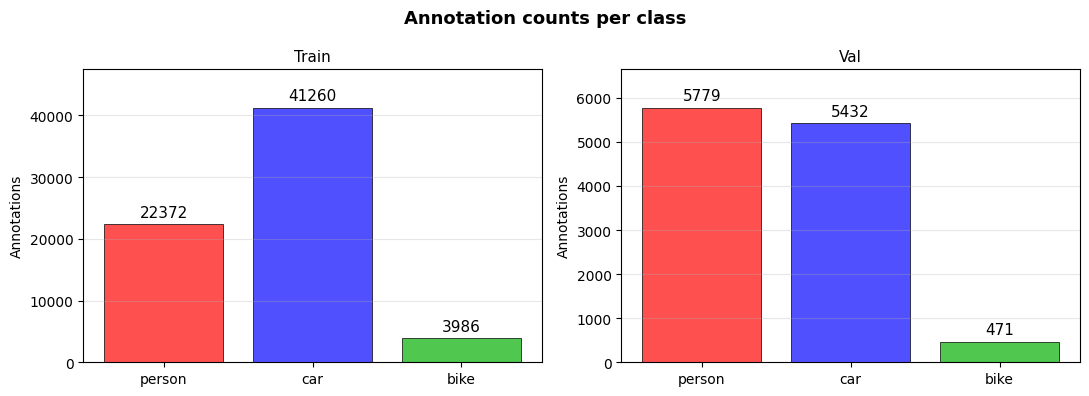

Saved: eda_class_distribution.png


In [5]:
def count_cls(coco, cat_map):
    c = Counter()
    for ann in coco['annotations']:
        if ann['category_id'] in cat_map:
            c[cat_map[ann['category_id']]] += 1
    return c

tr_cnt = count_cls(TRAIN_COCO, TRAIN_MAP)
va_cnt = count_cls(VAL_COCO,   VAL_MAP)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Annotation counts per class', fontsize=13, fontweight='bold')

for ax, cnt, title in [(axes[0], tr_cnt, 'Train'), (axes[1], va_cnt, 'Val')]:
    names  = [YOLO_NAMES[i] for i in range(N_CLS)]
    vals   = [cnt.get(i, 0) for i in range(N_CLS)]
    colors = [np.array(CLS_COLORS[i])/255 for i in range(N_CLS)]
    bars   = ax.bar(names, vals, color=colors, edgecolor='black', lw=0.5)
    ax.bar_label(bars, fmt='%d', fontsize=11, padding=3)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Annotations')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals) * 1.15)

plt.tight_layout()
fig.savefig(SAVE_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_class_distribution.png')


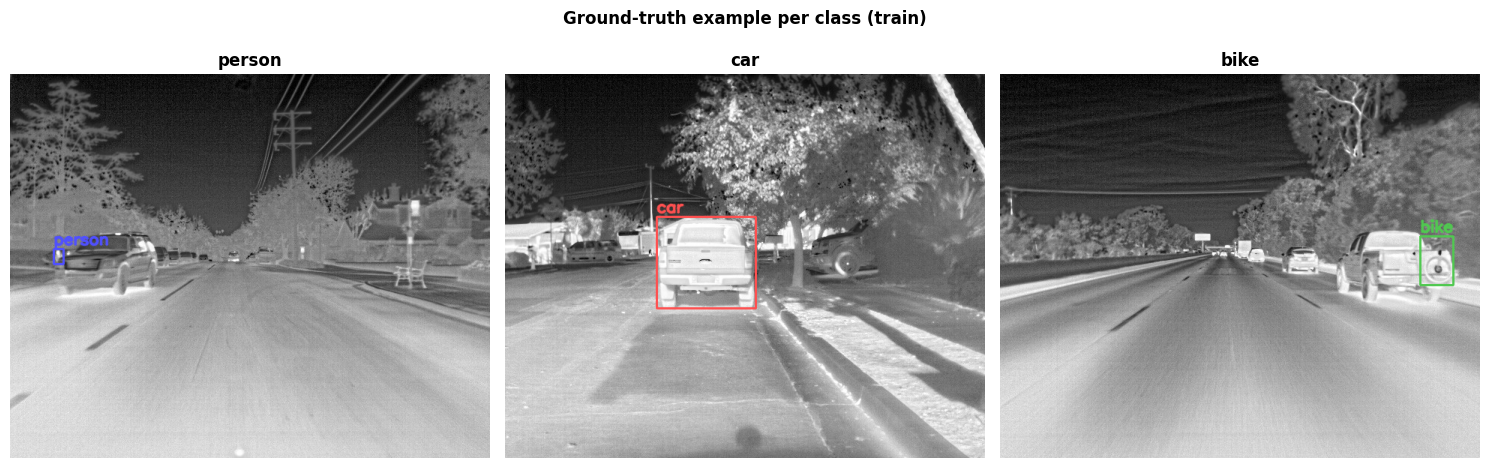

Saved: eda_class_examples.png


In [6]:
def find_class_examples(coco, cat_map, img_dir):
    examples = {}
    if 'images' in coco:
        id2file = {img['id']: Path(img['file_name']).name
                   for img in coco['images']}
    else:
        files   = sorted(img_dir.glob('*.jpeg'))
        id2file = {i: f.name for i, f in enumerate(files)}

    ann_by_img = defaultdict(list)
    for ann in coco['annotations']:
        if ann['category_id'] in cat_map:
            ann_by_img[ann['image_id']].append(ann)

    for img_id, anns in ann_by_img.items():
        if len(examples) == N_CLS:
            break
        fname = id2file.get(img_id)
        if not fname:
            continue
        img = cv2.imread(str(img_dir / fname))
        if img is None:
            continue
        for ann in anns:
            yid = cat_map[ann['category_id']]
            if yid not in examples:
                examples[yid] = (img.copy(), ann['bbox'])
    return examples


examples = find_class_examples(TRAIN_COCO, TRAIN_MAP, TRAIN_RAW/'thermal_8_bit')

fig, axes = plt.subplots(1, N_CLS, figsize=(5*N_CLS, 5))
fig.suptitle('Ground-truth example per class (train)',
             fontsize=12, fontweight='bold')

for ax, (yid, (img_bgr, bbox)) in zip(axes, sorted(examples.items())):
    vis = img_bgr.copy()
    bx, by, bw, bh = [int(v) for v in bbox]
    col = CLS_COLORS[yid]
    cv2.rectangle(vis, (bx, by), (bx+bw, by+bh), col, 2)
    cv2.putText(vis, YOLO_NAMES[yid], (bx, max(by-6, 14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2, cv2.LINE_AA)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(YOLO_NAMES[yid], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'eda_class_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_class_examples.png')


## 5 · Preprocessing Pipeline

| Step | Operation | Purpose |
|---|---|---|
| 1 | Min-Max normalisation | Equalise brightness across frames |
| 2 | Bilateral filter | Remove sensor noise, preserve edges |
| 3 | CLAHE | Boost local contrast |
| 4 | Unsharp mask | Sharpen object boundaries |
| 5 | Gray → 3-ch BGR | 3-channel input for YOLOv8 |

In [7]:
def min_max_norm(img):
    mn, mx = img.min(), img.max()
    return ((img - mn) / (mx - mn + 1e-6) * 255).astype(np.uint8)

def bilateral(img):
    return cv2.bilateralFilter(img, d=5, sigmaColor=15, sigmaSpace=15)

def clahe(img, clip=2.0, tile=8):
    op = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
    return op.apply(img)

def unsharp(img, strength=0.6):
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    return np.clip(
        cv2.addWeighted(img, 1+strength, blur, -strength, 0), 0, 255
    ).astype(np.uint8)

def full_pipeline(gray):
    s1 = min_max_norm(gray)
    s2 = bilateral(s1)
    s3 = clahe(s2)
    s4 = unsharp(s3)
    s5 = cv2.cvtColor(s4, cv2.COLOR_GRAY2BGR)
    return s1, s2, s3, s4, s5

print('Pipeline functions defined.')


Pipeline functions defined.


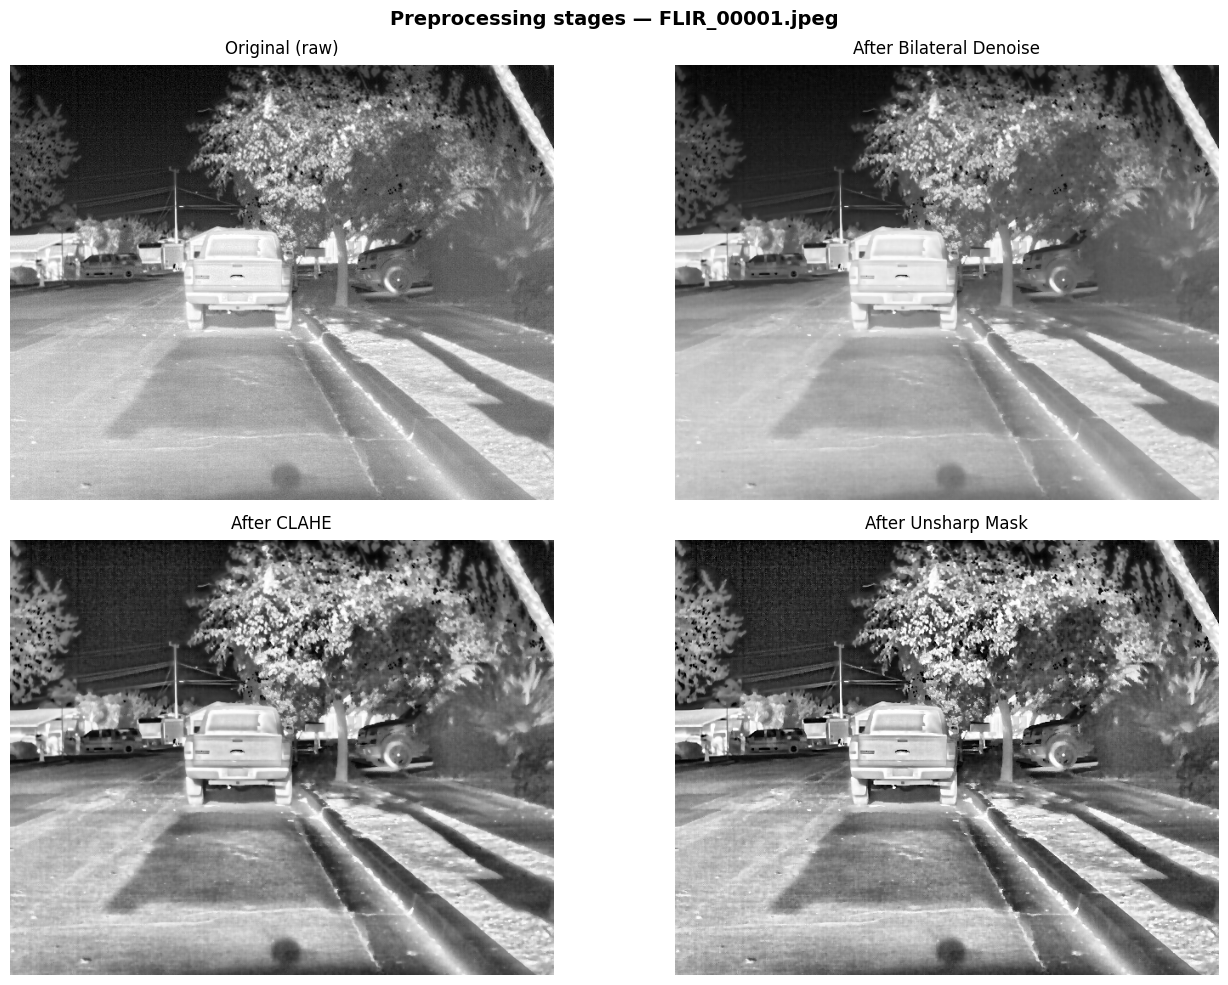

Saved: preprocessing_stages.png


In [8]:
# ---- 4 key stages in 2x2 grid (one sample image) -----------------------
sample_path = sorted((TRAIN_RAW/'thermal_8_bit').glob('*.jpeg'))[0]
raw_gray    = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
s1, s2, s3, s4, s5 = full_pipeline(raw_gray)

# 4 most visually informative stages — displayed in 2 rows
# No BGR->RGB conversion: all channels are equal in thermal 3ch output
stages_2x2 = [
    ('Original (raw)',       raw_gray),
    ('After Bilateral Denoise', s2),
    ('After CLAHE',          s3),
    ('After Unsharp Mask',   s4),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Preprocessing stages — {sample_path.name}',
    fontsize=14, fontweight='bold'
)

for ax, (title, img) in zip(axes.flat, stages_2x2):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, pad=8)
    ax.axis('off')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'preprocessing_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: preprocessing_stages.png')


In [9]:
# ---- Apply preprocessing to entire dataset --------------------------------
def apply_to_split(raw_img_dir, dst_img_dir):
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    jpegs = sorted(raw_img_dir.glob('*.jpeg'))
    tag   = dst_img_dir.parent.name + '/' + dst_img_dir.name
    for src in tqdm(jpegs, desc=tag):
        gray = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        *_, bgr = full_pipeline(gray)
        cv2.imwrite(
            str(dst_img_dir / (src.stem + '.jpg')),
            bgr, [cv2.IMWRITE_JPEG_QUALITY, 95]
        )

apply_to_split(TRAIN_RAW/'thermal_8_bit', DATASET_DIR/'images'/'train')
apply_to_split(VAL_RAW  /'thermal_8_bit', DATASET_DIR/'images'/'val')

for split in ['train', 'val']:
    imgs = {p.stem for p in (DATASET_DIR/'images'/split).glob('*.jpg')}
    lbls = {p.stem for p in (DATASET_DIR/'labels'/split).glob('*.txt')}
    print(f'[{split}] images={len(imgs)}  labels={len(lbls)}  paired={len(imgs & lbls)}')


images/train:   0%|          | 0/8862 [00:00<?, ?it/s]

images/val:   0%|          | 0/1366 [00:00<?, ?it/s]

[train] images=8862  labels=7859  paired=7859
[val] images=1366  labels=1360  paired=1360


## 6 · Bike Oversampling

`bike` is significantly underrepresented compared to `person` and `car`. We copy bike-containing images to partially rebalance the training set.

In [10]:
def count_images_with_cls(labels_dir, class_id):
    count = 0
    for lbl in labels_dir.glob('*.txt'):
        ids = [int(l.split()[0]) for l in
               lbl.read_text().strip().splitlines() if l.strip()]
        if class_id in ids:
            count += 1
    return count

tr_lbl = DATASET_DIR / 'labels' / 'train'
tr_img = DATASET_DIR / 'images' / 'train'

n_person = count_images_with_cls(tr_lbl, 0)
n_car    = count_images_with_cls(tr_lbl, 1)
n_bike   = count_images_with_cls(tr_lbl, 2)

print(f'Images containing class:  person={n_person}  car={n_car}  bike={n_bike}')

# Compute factor: target ~40% of max(person, car)
target = int(max(n_person, n_car) * 0.40)
factor = max(1, min(6, (target // max(n_bike, 1))))
print(f'Oversampling bike {factor}x  (target ~{target} images)')

if factor > 1:
    bike_lbls = [
        lbl for lbl in tr_lbl.glob('*.txt')
        if 2 in [int(l.split()[0]) for l in
                 lbl.read_text().strip().splitlines() if l.strip()]
    ]

    added = 0
    for copy_n in range(1, factor):
        for lbl_path in bike_lbls:
            img_path = tr_img / (lbl_path.stem + '.jpg')
            if not img_path.exists():
                continue
            stem = f'{lbl_path.stem}_os{copy_n}'
            shutil.copy2(img_path, tr_img / f'{stem}.jpg')
            shutil.copy2(lbl_path, tr_lbl / f'{stem}.txt')
            added += 1

    print(f'Added {added} copies.  Total bike images: {n_bike + added}')
else:
    print('No oversampling needed (classes already balanced).')

# Final counts
total_train = len(list(tr_img.glob('*.jpg')))
print(f'Total train images after oversampling: {total_train}')


Images containing class:  person=5838  car=7379  bike=1762
Oversampling bike 1x  (target ~2951 images)
No oversampling needed (classes already balanced).
Total train images after oversampling: 8862


## 7 · Training — Single Phase

| Setting | Value | Reason |
|---|---|---|
| Epochs | 20 | Enough for convergence on small dataset |
| `lr0` | 1e-4 (head) / 1e-5 (backbone) | Differential LR via callback |
| `warmup_epochs` | 5 | Warmup replaces the old Phase-1 freeze |
| `fliplr` | 0.5 | Only safe augmentation for thermal |
| All other aug | 0 | Preserve thermal radiometric values |

**Differential LR** — a `on_train_start` callback splits the Ultralytics optimizer into backbone (`layers 0-9`, lr/10) and head (`layers 10+`, lr) parameter groups. The scheduler then scales each group independently.

In [12]:
# ---- Differential LR callback --------------------------------------------
def apply_differential_lr(trainer):
    try:
        opt = trainer.optimizer

        # Backbone = YOLOv8 layers 0-9
        backbone_ids = set()
        for name, p in trainer.model.named_parameters():
            for part in name.split('.'):
                if part.isdigit():
                    if int(part) < 10:
                        backbone_ids.add(id(p))
                    break

        # Split each existing param group into backbone / head sub-groups
        new_groups = []
        for pg in opt.param_groups:
            bb_params = [p for p in pg['params'] if id(p) in backbone_ids]
            hd_params = [p for p in pg['params'] if id(p) not in backbone_ids]

            if bb_params:
                bb = {k: v for k, v in pg.items() if k != 'params'}
                bb['params']     = bb_params
                bb['lr']         = pg['lr'] / 10
                bb['initial_lr'] = pg.get('initial_lr', pg['lr']) / 10
                new_groups.append(bb)

            if hd_params:
                hd = {k: v for k, v in pg.items() if k != 'params'}
                hd['params'] = hd_params
                new_groups.append(hd)

        opt.param_groups = new_groups

        # Sync scheduler base_lrs so cosine/warmup schedule stays correct
        if hasattr(trainer, 'scheduler') and hasattr(trainer.scheduler, 'base_lrs'):
            trainer.scheduler.base_lrs = [
                pg['initial_lr'] for pg in new_groups
            ]
            # ← FIX: lr_lambdas must match the new number of param groups
            if hasattr(trainer.scheduler, 'lr_lambdas'):
                original_lambda = trainer.scheduler.lr_lambdas[0]
                trainer.scheduler.lr_lambdas = [original_lambda] * len(new_groups)

        n_bb = sum(len(pg['params']) for pg in new_groups
                   if pg.get('initial_lr', 1) < trainer.args.lr0 * 0.5)
        n_hd = sum(len(pg['params']) for pg in new_groups
                   if pg.get('initial_lr', 0) >= trainer.args.lr0 * 0.5)
        print(f'  Differential LR applied:')
        print(f'    Backbone ({n_bb} tensors): lr = {trainer.args.lr0/10:.1e}')
        print(f'    Head     ({n_hd} tensors): lr = {trainer.args.lr0:.1e}')

    except Exception as exc:
        print(f'  [WARN] Differential LR not applied: {exc}')
        print(f'  Using uniform lr = {trainer.args.lr0:.1e}')


# ---- Load model and register callback ------------------------------------
model = YOLO('yolov8s.pt')
model.add_callback('on_train_start', apply_differential_lr)

# ---- Train ---------------------------------------------------------------
model.train(
    data=str(YAML_PATH),
    epochs=20,
    imgsz=640,
    batch=-1,
    lr0=1e-4,
    lrf=0.01,
    warmup_epochs=5,
    warmup_bias_lr=0.1,
    # ---- only horizontal flip, no other augmentation ----
    fliplr=0.5,
    flipud=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    perspective=0.0, mosaic=0.0, mixup=0.0, copy_paste=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    # -------------------------------------------------
    workers=2,
    project=str(RUNS_DIR),
    name='single_phase',
    exist_ok=True,
)

FINAL_WEIGHTS = RUNS_DIR / 'single_phase' / 'weights' / 'best.pt'
print('\nBest weights:', FINAL_WEIGHTS)


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/flir_work/flir_thermal.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=single_phase, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

## 8 · Training Curves

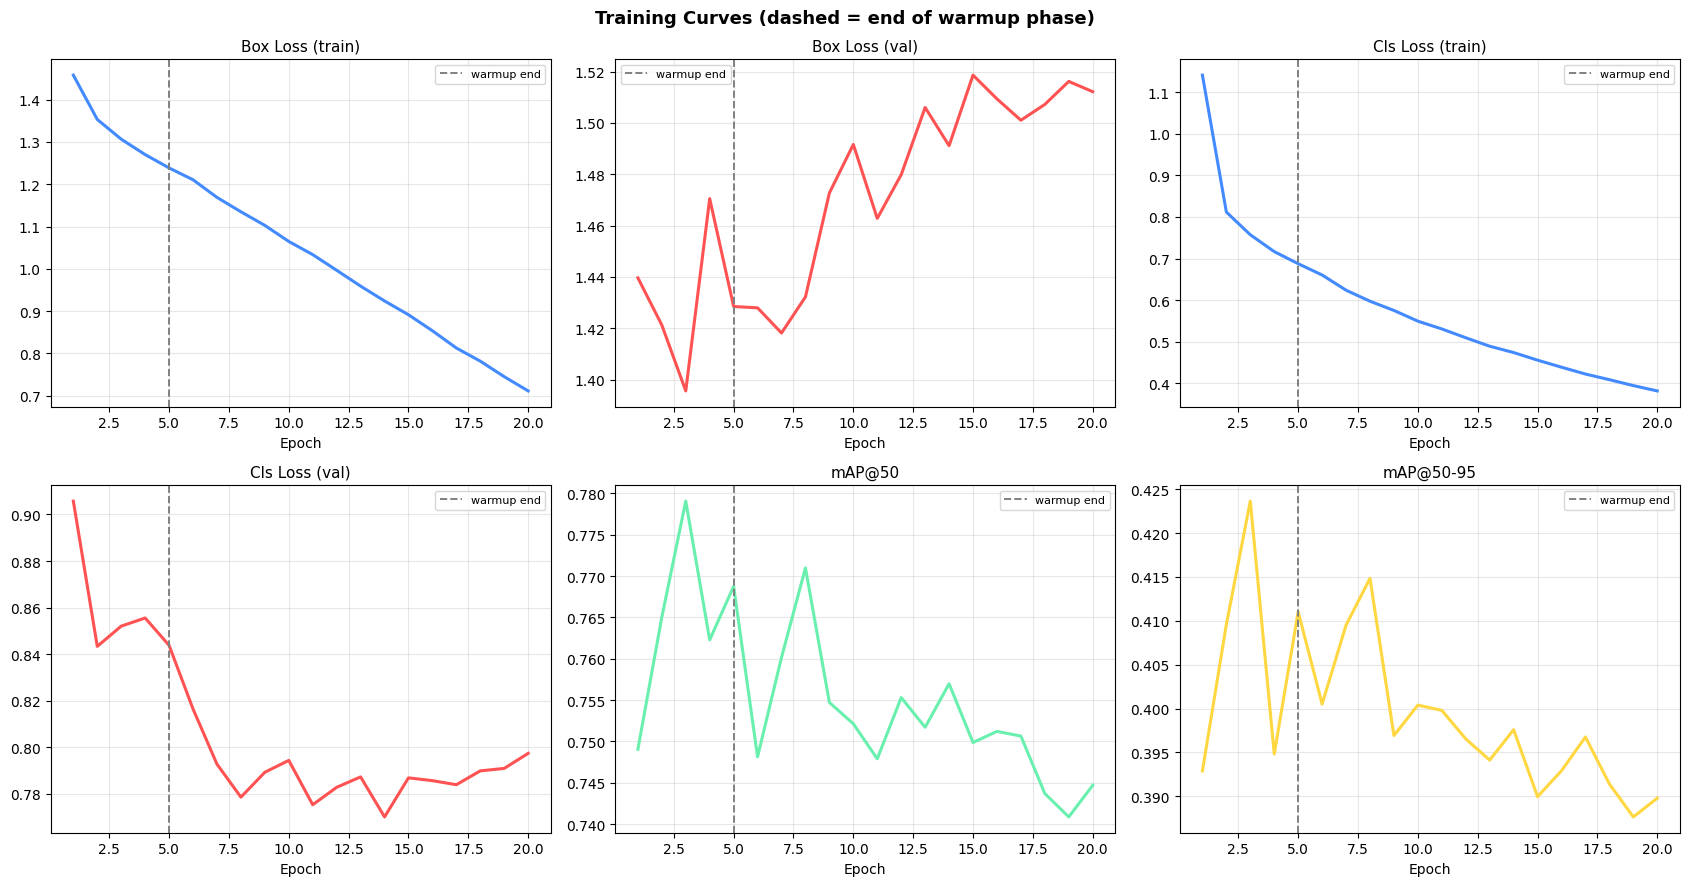

Saved: training_curves.png


In [13]:
csv_path = RUNS_DIR / 'single_phase' / 'results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

PLOTS = [
    ('train/box_loss',       'Box Loss (train)',  '#448AFF'),
    ('val/box_loss',         'Box Loss (val)',    '#FF5252'),
    ('train/cls_loss',       'Cls Loss (train)',  '#448AFF'),
    ('val/cls_loss',         'Cls Loss (val)',    '#FF5252'),
    ('metrics/mAP50(B)',     'mAP@50',            '#69F0AE'),
    ('metrics/mAP50-95(B)',  'mAP@50-95',         '#FFD740'),
]

# Warmup boundary (epoch 5)
warmup_end = 5

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Training Curves (dashed = end of warmup phase)',
             fontsize=13, fontweight='bold')

for ax, (col, title, color) in zip(axes.flat, PLOTS):
    if col not in df.columns:
        ax.set_visible(False); continue
    ax.plot(df['epoch'], df[col], color=color, lw=2.2)
    ax.axvline(warmup_end, color='gray', ls='--', lw=1.4, label='warmup end')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')


## 9 · Evaluation Metrics

- **mAP@50 / mAP@50-95** — official YOLO detection metrics
- **Precision / Recall / F1** — per class and macro
- **MCC** — Matthews Correlation Coefficient
- **Classification report + Confusion matrix** — matched GT boxes (IoU ≥ 0.5)

In [14]:
FINAL = YOLO(str(FINAL_WEIGHTS))

print('Running YOLO validation...')
vr = FINAL.val(data=str(YAML_PATH), verbose=False)

print(f'\n  mAP@50      : {vr.box.map50:.4f}')
print(f'  mAP@50-95   : {vr.box.map:.4f}')
print(f'  Precision   : {vr.box.mp:.4f}')
print(f'  Recall      : {vr.box.mr:.4f}')

print('\nPer-class mAP@50:')
try:
    ap_idx = (vr.box.ap_class_index
              if hasattr(vr.box, 'ap_class_index')
              else list(range(len(vr.box.ap50))))
    for i, ap50 in enumerate(vr.box.ap50):
        idx   = ap_idx[i]
        f1v   = 2*vr.box.p[i]*vr.box.r[i] / (vr.box.p[i]+vr.box.r[i]+1e-6)
        print(f'  {YOLO_NAMES.get(idx, idx):<8}  '
              f'AP50={ap50:.3f}  P={vr.box.p[i]:.3f}  '
              f'R={vr.box.r[i]:.3f}  F1={f1v:.3f}')
except Exception as e:
    print(f'  (per-class details: {e})')


Running YOLO validation...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3050.7±1105.1 MB/s, size: 145.5 KB)
val: Scanning /content/flir_work/dataset/labels/val.cache... 1360 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1366/1366 477.5Mit/s 0.0s
val: /content/flir_work/dataset/images/val/FLIR_09042.jpg: 1 duplicate labels removed
val: /content/flir_work/dataset/images/val/FLIR_09055.jpg: 1 duplicate labels removed
val: /content/flir_work/dataset/images/val/FLIR_09653.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 86/86 4.2it/s 20.5s
                   all       1366      11679      0.781        0.7      0.778      0.424
Speed: 1.5ms preprocess, 7.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /con

In [15]:
# ---- Inference-based evaluation (sklearn metrics) ------------------------
VAL_IMGS_DIR = DATASET_DIR / 'images' / 'val'
VAL_LBL_DIR  = DATASET_DIR / 'labels' / 'val'

def xywhn2xyxy(b):
    xc,yc,w,h = b[1],b[2],b[3],b[4]
    return [xc-w/2, yc-h/2, xc+w/2, yc+h/2]

def iou(a, b):
    x1,y1 = max(a[0],b[0]), max(a[1],b[1])
    x2,y2 = min(a[2],b[2]), min(a[3],b[3])
    inter  = max(0,x2-x1)*max(0,y2-y1)
    union  = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/(union+1e-6)

y_true, y_pred = [], []

for img_path in tqdm(sorted(VAL_IMGS_DIR.glob('*.jpg')), desc='Evaluating'):
    lbl_path = VAL_LBL_DIR / (img_path.stem + '.txt')

    gt = []
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            p = line.split()
            if len(p) == 5:
                gt.append([int(p[0])] + [float(x) for x in p[1:]])

    res   = FINAL.predict(str(img_path), conf=CONF_THRESH, verbose=False)[0]
    preds = []
    if res.boxes is not None and len(res.boxes):
        for box in res.boxes:
            preds.append([int(box.cls)] +
                          box.xywhn[0].cpu().numpy().tolist())

    gt_xy   = [xywhn2xyxy(g) for g in gt]
    pred_xy = [xywhn2xyxy(p) for p in preds]

    matched_gt = set()
    for pi, pred in enumerate(preds):
        best_v, best_gi = 0.0, -1
        for gi, g in enumerate(gt):
            if gi in matched_gt or g[0] != pred[0]:
                continue
            v = iou(pred_xy[pi], gt_xy[gi])
            if v > best_v:
                best_v, best_gi = v, gi
        if best_v >= 0.5 and best_gi >= 0:
            matched_gt.add(best_gi)

    for gi, g in enumerate(gt):
        y_true.append(g[0])
        y_pred.append(g[0] if gi in matched_gt else N_CLS)  # N_CLS = 'missed'

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(f'Evaluated {len(y_true)} GT boxes  (conf threshold = {CONF_THRESH})')


Evaluating:   0%|          | 0/1366 [00:00<?, ?it/s]

Evaluated 11682 GT boxes  (conf threshold = 0.15)


In [16]:
# ---- Sklearn report -------------------------------------------------------
tgt_names = [YOLO_NAMES[i] for i in range(N_CLS)] + ['missed']

print('Classification Report (per GT box, IoU >= 0.5)\n')
print(classification_report(
    y_true, y_pred,
    labels=list(range(N_CLS + 1)),
    target_names=tgt_names,
    zero_division=0
))

f1_per = f1_score(y_true, y_pred, labels=list(range(N_CLS)),
                   average=None, zero_division=0)
f1_mac = f1_score(y_true, y_pred, labels=list(range(N_CLS)),
                   average='macro', zero_division=0)
mcc    = matthews_corrcoef(y_true, y_pred)

print('F1 per class:')
for i, v in enumerate(f1_per):
    print(f'  {YOLO_NAMES[i]:<8}: {v:.4f}')
print(f'F1 macro  : {f1_mac:.4f}')
print(f'MCC       : {mcc:.4f}')


Classification Report (per GT box, IoU >= 0.5)

              precision    recall  f1-score   support

      person       1.00      0.87      0.93      5779
         car       1.00      0.92      0.96      5432
        bike       1.00      0.73      0.84       471
      missed       0.00      0.00      0.00         0

    accuracy                           0.89     11682
   macro avg       0.75      0.63      0.68     11682
weighted avg       1.00      0.89      0.94     11682

F1 per class:
  person  : 0.9300
  car     : 0.9560
  bike    : 0.8413
F1 macro  : 0.9091
MCC       : 0.8199


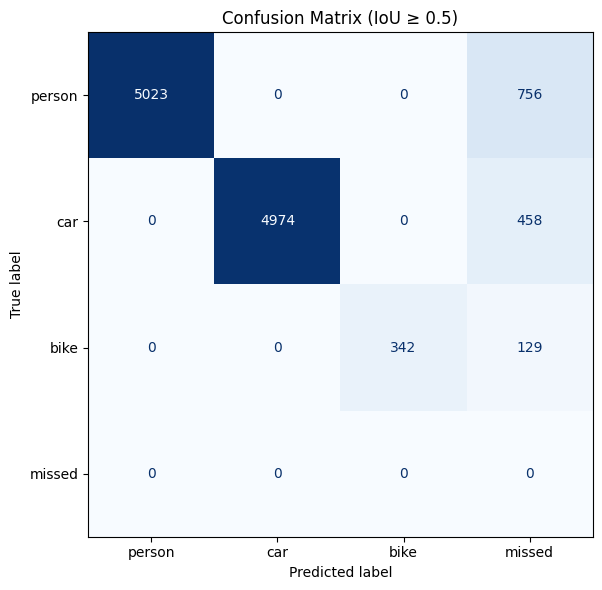

Saved: confusion_matrix.png


In [17]:
# ---- Confusion matrix -----------------------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLS + 1)))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    cm,
    display_labels=tgt_names
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (IoU ≥ 0.5)', fontsize=12)
plt.tight_layout()
fig.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')


## 10 · Detection Examples

2 successful detections per class at conf ≥ 0.35.

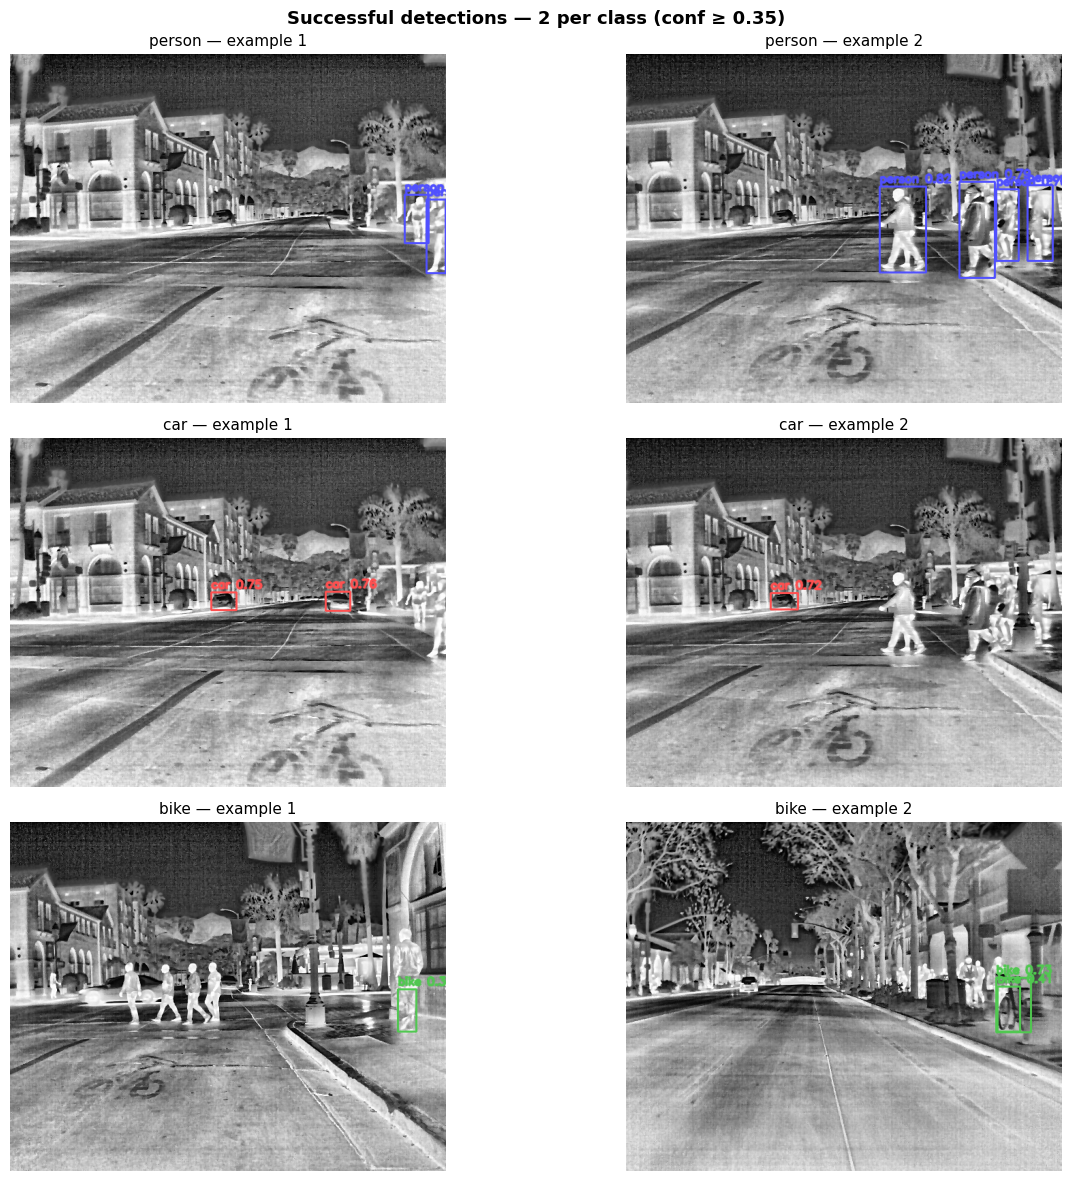

Saved: detection_examples.png


In [26]:
detected = defaultdict(list)
CONF_THRESH = 0.35

for img_path in sorted(VAL_IMGS_DIR.glob('*.jpg')):
    if len(detected) == N_CLS and all(len(v) >= 2 for v in detected.values()):
        break

    res = FINAL.predict(str(img_path), conf=CONF_THRESH, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        continue

    img_bgr = cv2.imread(str(img_path))
    seen    = set()

    for box in res.boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        if cls not in YOLO_NAMES or conf < CONF_THRESH:
            continue
        if cls in seen or len(detected[cls]) >= 2:
            continue
        seen.add(cls)

        drawn = img_bgr.copy()
        for b in res.boxes:
            if int(b.cls) != cls:
                continue
            x1, y1, x2, y2 = map(int, b.xyxy[0].cpu().numpy())
            col = CLS_COLORS[cls]
            cv2.rectangle(drawn, (x1,y1), (x2,y2), col, 2)
            lbl = f'{YOLO_NAMES[cls]} {float(b.conf):.2f}'
            cv2.putText(drawn, lbl, (x1, max(y1-6, 14)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2, cv2.LINE_AA)
        detected[cls].append(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))

cls_found = sorted(detected.keys())
n_rows    = len(cls_found)

if n_rows == 0:
    print(f'No detections found at conf={CONF_THRESH}.')
else:
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4*n_rows))
    if n_rows == 1:
        axes = np.array([axes])
    fig.suptitle(
        f'Successful detections — 2 per class (conf ≥ {CONF_THRESH})',
        fontsize=13, fontweight='bold'
    )

    for row, cls_id in enumerate(cls_found):
        for col in range(2):
            ax = axes[row, col]
            if col < len(detected[cls_id]):
                ax.imshow(detected[cls_id][col])
                ax.set_title(
                    f'{YOLO_NAMES[cls_id]} — example {col+1}', fontsize=11)
            else:
                ax.text(0.5, 0.5, 'No example found',
                        ha='center', va='center',
                        transform=ax.transAxes, fontsize=12, color='gray')
            ax.axis('off')

    plt.tight_layout()
    fig.savefig(SAVE_DIR / 'detection_examples.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: detection_examples.png')


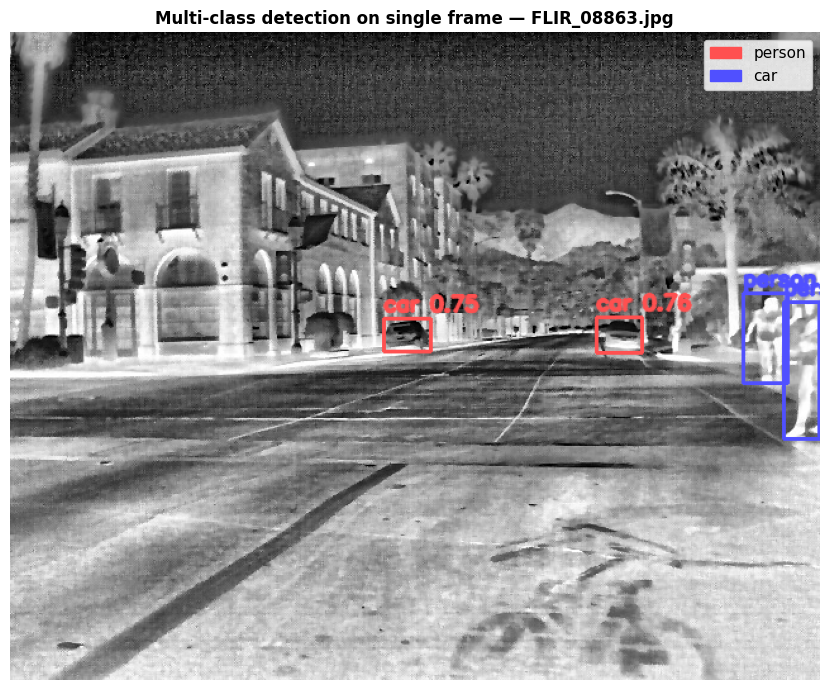

Classes detected: ['person', 'car']
Saved: detection_multiclass.png


In [27]:
# ---- One image with multiple classes detected simultaneously --------
multi_class_img = None
CONF_THRESH = 0.35

for img_path in sorted(VAL_IMGS_DIR.glob('*.jpg')):
    res = FINAL.predict(str(img_path), conf=CONF_THRESH, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0:
        continue

    classes_in_img = set(int(b.cls) for b in res.boxes)
    if len(classes_in_img) >= 2:          # at least 2 different classes
        multi_class_img = (img_path, res)
        break

if multi_class_img is None:
    print('No image with 2+ classes found. Try lowering CONF_THRESH.')
else:
    img_path, res = multi_class_img
    drawn = cv2.imread(str(img_path))

    for box in res.boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        col = CLS_COLORS.get(cls, (200, 200, 200))
        cv2.rectangle(drawn, (x1, y1), (x2, y2), col, 2)
        cv2.putText(drawn, f'{YOLO_NAMES.get(cls, cls)} {conf:.2f}',
                    (x1, max(y1 - 6, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2, cv2.LINE_AA)

    classes_shown = sorted({int(b.cls) for b in res.boxes})
    legend = [mpatches.Patch(color=np.array(CLS_COLORS[c])/255,
                              label=YOLO_NAMES[c])
              for c in classes_shown if c in CLS_COLORS]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Multi-class detection on single frame — {img_path.name}',
                 fontsize=12, fontweight='bold')
    ax.legend(handles=legend, loc='upper right', fontsize=11,
              framealpha=0.85)
    ax.axis('off')

    plt.tight_layout()
    fig.savefig(SAVE_DIR / 'detection_multiclass.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Classes detected: {[YOLO_NAMES[c] for c in classes_shown]}')
    print('Saved: detection_multiclass.png')

In [30]:
import shutil, os, zipfile
from pathlib import Path
from google.colab import files

WORK_DIR  = Path('/content/flir_work')
ZIP_PATH  = '/content/flir_export.zip'
INCLUDE   = ['outputs', 'runs']

print('Архівування...')
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in INCLUDE:
        src = WORK_DIR / folder
        if not src.exists():
            print(f'  [ПРОПУЩЕНО] {src} не існує')
            continue
        for file in src.rglob('*'):
            if file.is_file():
                arcname = file.relative_to(WORK_DIR)
                zf.write(file, arcname)
        print(f'  [OK] {folder}/')

size_mb = Path(ZIP_PATH).stat().st_size / 1e6
print(f'\nГотово: {ZIP_PATH}  ({size_mb:.1f} MB)')
print('Завантаження...')
files.download(ZIP_PATH)

Архівування...
  [OK] outputs/
  [OK] runs/

Готово: /content/flir_export.zip  (56.3 MB)
Завантаження...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>